In [3]:
import pandas as pd

df = pd.read_csv('../samokat_esci.csv')

df

,query,item_name,item_id,final_answer,category4_name,category3_name,category2_name,category1_name
0,энергетик без сахара,"энергетик самокат, без сахара, с соком малины,...",55e4ae6a298cf3f69d8e07a92ec9e6a0,e,энергетические напитки,энергетические напитки,напитки,безалкогольные напитки
1,салат из рубца,"салат кх волкова а. п. деревенский, 150 г",b429835fc94f84edf3e319f01ce35274,s,салаты с майонезом,салаты,готовые блюда,кулинария
2,барилла,"макароны barilla, пенне ригате, 450 г",a2f84d68a96b5f95e3b72ff3f664e1e6,e,фигурные,"спагетти, фигурные",макаронные изделия,бакалея
3,краска для волос орех,"спрей-уход для наращенных волос tashe 250 мл, ...",227b20c1eee7ba92f52dfaf6fe9c05c4,c,натуральные краски для волос,краска для волос,средства по уходу за волосами,уход
4,творог мя,"творог козочка с облачка, 5%, мягкий, из козье...",05180ad0ea61952acd22c82f5740c47b,e,мягкий творог,творог,кисломолочные традиционные продукты,молочная продукция
...,...,...,...,...,...,...,...,...
79769,агар агара,"креветки agama, королевские, очищенные, для па...",6f1e42ba8b662fec4eda5a152dcc4b08,i,ракообразные замороженные,морепродукты замороженные,рыба замороженная,замороженные продукты
79770,рукп,"крем для рук самокат, жасмин и сандал, 30 мл",9ea9202f380cb275ef31de5ba033d736,e,увлажнение и питание кожи рук,увлажнение и питание кожи рук,уход за кожей рук,уход
79771,аджастер,"женские кроссовки geox d adacter w, бежевые, 3...",894e4ca5d1d3db3a4b135968cf04004e,i,кроссовки для женщин,"кеды, кроссовки, слипоны для женщин","кеды, кроссовки, слипоны",обувь
79772,форма лед,"формы для льда marmiton, звёзды, 3,5x3,5 см, 6...",68ac9287641d14ea0b5013a0391c1337,e,формы для льда,аксессуары для сервировки,сервировка стола,ремонт и обустройство дома


## предобработка

In [4]:
esci_codes_dict = {'e':3, 's':2, 'c':1, 'i':0}
df['final_answer'].value_counts().sort_index(key = lambda letter: letter.map(esci_codes_dict), ascending=False)

final_answer
e    36474
s     9307
c     4833
i    29160
Name: count, dtype: int64

In [5]:
import numpy as np

df['target_ESC_vs_I'] = df['final_answer'].replace({'e':1, 's':1, 'c':1, 'i':0}).astype(int)
df['target_ESC'] = df['final_answer'].replace({'e':3, 's':2, 'c':1, 'i':0}).astype(int)
df

,query,item_name,item_id,final_answer,category4_name,category3_name,category2_name,category1_name,target_ESC_vs_I,target_ESC
0,энергетик без сахара,"энергетик самокат, без сахара, с соком малины,...",55e4ae6a298cf3f69d8e07a92ec9e6a0,e,энергетические напитки,энергетические напитки,напитки,безалкогольные напитки,1,3
1,салат из рубца,"салат кх волкова а. п. деревенский, 150 г",b429835fc94f84edf3e319f01ce35274,s,салаты с майонезом,салаты,готовые блюда,кулинария,1,2
2,барилла,"макароны barilla, пенне ригате, 450 г",a2f84d68a96b5f95e3b72ff3f664e1e6,e,фигурные,"спагетти, фигурные",макаронные изделия,бакалея,1,3
3,краска для волос орех,"спрей-уход для наращенных волос tashe 250 мл, ...",227b20c1eee7ba92f52dfaf6fe9c05c4,c,натуральные краски для волос,краска для волос,средства по уходу за волосами,уход,1,1
4,творог мя,"творог козочка с облачка, 5%, мягкий, из козье...",05180ad0ea61952acd22c82f5740c47b,e,мягкий творог,творог,кисломолочные традиционные продукты,молочная продукция,1,3
...,...,...,...,...,...,...,...,...,...,...
79769,агар агара,"креветки agama, королевские, очищенные, для па...",6f1e42ba8b662fec4eda5a152dcc4b08,i,ракообразные замороженные,морепродукты замороженные,рыба замороженная,замороженные продукты,0,0
79770,рукп,"крем для рук самокат, жасмин и сандал, 30 мл",9ea9202f380cb275ef31de5ba033d736,e,увлажнение и питание кожи рук,увлажнение и питание кожи рук,уход за кожей рук,уход,1,3
79771,аджастер,"женские кроссовки geox d adacter w, бежевые, 3...",894e4ca5d1d3db3a4b135968cf04004e,i,кроссовки для женщин,"кеды, кроссовки, слипоны для женщин","кеды, кроссовки, слипоны",обувь,0,0
79772,форма лед,"формы для льда marmiton, звёзды, 3,5x3,5 см, 6...",68ac9287641d14ea0b5013a0391c1337,e,формы для льда,аксессуары для сервировки,сервировка стола,ремонт и обустройство дома,1,3


In [6]:
# from transformers import AutoTokenizer, AutoModel
# 
# model_name = "d0rj/e5-small-en-ru"
# tokenizer = AutoTokenizer.from_pretrained(model_name)
# model = AutoModel.from_pretrained(model_name)
# model.eval() # уже обучилась, просто чтобы не 

### лемматизация query и item_name

In [7]:
# =========================================================
# 1. Лемматизация
# =========================================================

import re
import pymorphy3

morph = pymorphy3.MorphAnalyzer()

def lemmatize_text(text):
    text = text.lower()
    text = re.sub(r'[^\w\s]', ' ', text)      # убрать пунктуацию
    text = re.sub(r'\d+', ' ', text)          # убрать цифры
    text = re.sub(r'\s+', ' ', text).strip()  # все пробельные -> один пробел

    words = text.split()
    words = [w for w in words if len(w) > 2]  # убрать слова из 2 букв

    lemmas = [morph.parse(w)[0].normal_form for w in words]
    return ' '.join(lemmas)

# df['query_lemma'] = df['query'].apply(lemmatize_text)
# df['item_name_lemma'] = df['item_name'].apply(lemmatize_text)

### word_overlap

In [8]:
# ==========================================================
# 2. Доля слов запроса, встречающихся в названии (по леммам)
#    1.0 -- если все слова в query есть в item_name  
# ==========================================================

# def word_overlap_ratio(query, item_name):
#     q_words = set(query.split())
#     i_words = set(item_name.split())
#     if not q_words:
#         return 0.0
#     return len(q_words & i_words) / len(q_words)
# 
# df['word_overlap'] = df.apply(
#     lambda r: word_overlap_ratio(r['query_lemma'], r['item_name_lemma']), axis=1
# )

# df

from sklearn.base import BaseEstimator, TransformerMixin

class WordOverlapTransformer(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self

    def transform(self, X):
        q_lemma = X['query'].apply(lemmatize_text)
        i_lemma = X['item_name'].apply(lemmatize_text)
        def ratio(q, i):
            q_words, i_words = set(q.split()), set(i.split())
            return len(q_words & i_words) / len(q_words) if q_words else 0.0
        result = [ratio(q, i) for q, i in zip(q_lemma, i_lemma)]
        return np.array(result).reshape(-1, 1)

In [9]:
# df['word_overlap'].value_counts().sort_index()

### substring_ratio

In [10]:
# =========================================================
# 3. Совпадение по подстрокам
#    как-то хитро считает насколько похожа первая строка на вторую (не только по включениям)
# =========================================================

from difflib import SequenceMatcher

# def substring_ratio(query, item_name):
#     return SequenceMatcher(None, query, item_name).ratio()
# 
# df['substring_ratio'] = df.apply(
#     lambda r: substring_ratio(r['query_lemma'], r['item_name_lemma']), axis=1
# )

# df

class SubstringRatioTransformer(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self

    def transform(self, X):
        q_lemma = X['query'].apply(lemmatize_text)
        i_lemma = X['item_name'].apply(lemmatize_text)
        result = [SequenceMatcher(None, q, i).ratio() for q, i in zip(q_lemma, i_lemma)]
        return np.array(result).reshape(-1, 1)

### tfidf_sim

In [11]:
# =========================================================
# 4. TF-IDF сходство (на леммах)
# =========================================================

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# tfidf = TfidfVectorizer()
# tfidf.fit(pd.concat([df['query_lemma'], df['item_name_lemma']]))
# 
# q_vecs = tfidf.transform(df['query_lemma']) # вектор -- высоты датасета
# i_vecs = tfidf.transform(df['item_name_lemma']) # вектор -- высоты датасета
# 
# df['tfidf_sim'] = [
#     cosine_similarity(q_vecs[i], i_vecs[i])[0][0] for i in range(len(df))
# ]

# df

class TfidfSimTransformer(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        q_lemma = X['query'].apply(lemmatize_text)
        i_lemma = X['item_name'].apply(lemmatize_text)
        self.tfidf = TfidfVectorizer()
        self.tfidf.fit(pd.concat([q_lemma, i_lemma]))
        return self

    def transform(self, X):
        q_lemma = X['query'].apply(lemmatize_text)
        i_lemma = X['item_name'].apply(lemmatize_text)
        q_vecs = self.tfidf.transform(q_lemma)
        i_vecs = self.tfidf.transform(i_lemma)
        sims = [cosine_similarity(q_vecs[i], i_vecs[i])[0][0] for i in range(X.shape[0])]
        return np.array(sims).reshape(-1, 1)

### emb_cos_sim

In [12]:
# =========================================================
# 5. Эмбеддинги (d0rj/e5-small-en-ru) + косинусное сходство
# =========================================================

from transformers import AutoTokenizer, AutoModel

model_name = "d0rj/e5-small-en-ru"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name)
model.eval() # уже обучилась, просто чтобы не 

/Users/chumbulev/PycharmProjects/LSH2026/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 199/199 [00:00<00:00, 7126.23it/s]


XLMRobertaModel(
  (embeddings): XLMRobertaEmbeddings(
    (word_embeddings): Embedding(60302, 384, padding_idx=0)
    (token_type_embeddings): Embedding(2, 384)
    (LayerNorm): LayerNorm((384,), eps=1e-12, elementwise_affine=True, bias=True)
    (dropout): Dropout(p=0.1, inplace=False)
    (position_embeddings): Embedding(512, 384, padding_idx=0)
  )
  (encoder): XLMRobertaEncoder(
    (layer): ModuleList(
      (0-11): 12 x XLMRobertaLayer(
        (attention): XLMRobertaAttention(
          (self): XLMRobertaSelfAttention(
            (query): Linear(in_features=384, out_features=384, bias=True)
            (key): Linear(in_features=384, out_features=384, bias=True)
            (value): Linear(in_features=384, out_features=384, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (output): XLMRobertaSelfOutput(
            (dense): Linear(in_features=384, out_features=384, bias=True)
            (LayerNorm): LayerNorm((384,), eps=1e-12, elementwise_

In [33]:
import torch
from tqdm import tqdm

def mean_pooling(model_output, attention_mask): # средний эмбеддинг по предложению
    token_embeddings = model_output[0]
    mask = attention_mask.unsqueeze(-1).expand(token_embeddings.size()).float()
    return (token_embeddings * mask).sum(1) / mask.sum(1).clamp(min=1e-9)

def embed_texts(texts, tokenizer, model, batch_size=32, prefix="query: "):
    embeddings = []
    for i in tqdm(range(0, len(texts), batch_size), desc=f"Embedding ({prefix.strip()})"):
        batch = [f"{prefix}{t}" for t in texts[i:i+batch_size]]
        enc = tokenizer(batch, padding=True, truncation=True, return_tensors='pt')
        with torch.no_grad():
            out = model(**enc)
        emb = mean_pooling(out, enc['attention_mask'])
        emb = torch.nn.functional.normalize(emb, p=2, dim=1)
        embeddings.append(emb.numpy())
    return np.vstack(embeddings)

# query_emb = embed_texts(df['query'].tolist(), prefix="query: ")
# item_emb = embed_texts(df['item_name'].tolist(), prefix="passage: ")
# 
# df['emb_cos_sim'] = (query_emb * item_emb).sum(axis=1) # без нормы т.к. они уже || || = 1
# 
# df

class EmbSimTransformer(BaseEstimator, TransformerMixin):
    _cache = {}

    def __init__(self, tokenizer, model):
        self.tokenizer = tokenizer
        self.model = model

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        key = tuple(X.index)
        if key in self._cache:
            return self._cache[key]

        q_emb = embed_texts(X['query'].tolist(), self.tokenizer, self.model, prefix="query: ")
        i_emb = embed_texts(X['item_name'].tolist(), self.tokenizer, self.model, prefix="passage: ")
        result = (q_emb * i_emb).sum(axis=1).reshape(-1, 1)

        self._cache[key] = result
        return result

#### PCA по emb_cos_sim

In [ ]:
from sklearn.decomposition import PCA
import seaborn as sns
import matplotlib.pyplot as plt

query_emb_full = embed_texts(df['query'].tolist(), tokenizer, model, prefix="query: ")
item_emb_full = embed_texts(df['item_name'].tolist(), tokenizer, model, prefix="passage: ")

In [88]:
diff_emb_abs = np.abs(query_emb_full - item_emb_full)

pca = PCA(n_components=2)
coords = pca.fit_transform(diff_emb_abs)

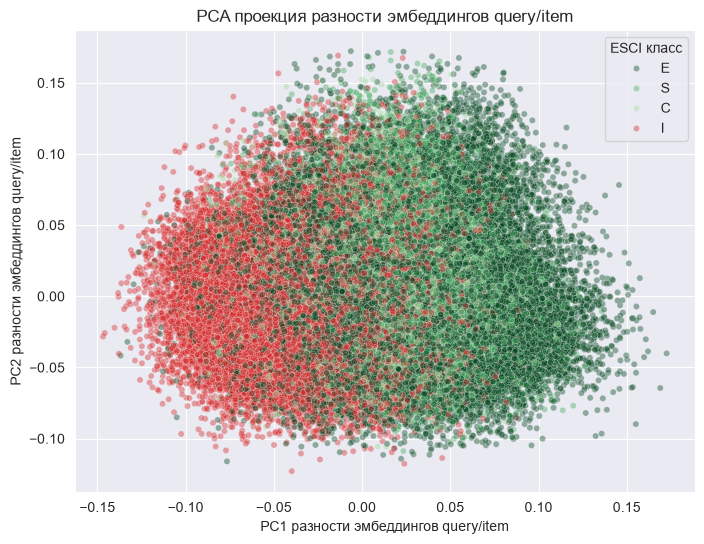

In [89]:
esci_labels = df['final_answer'].str.upper()  # E/S/C/I для читаемой легенды

custom_palette = {
    'E': '#00441b',   # тёмно-зелёный
    'S': '#41ab5d',   # средний зелёный
    'C': '#a1d99b',   # светло-зелёный
    'I': '#d62728',   # красный
}

plt.figure(figsize=(8, 6))
sns.scatterplot(
    x=coords[:, 0], y=coords[:, 1],
    hue=esci_labels, hue_order=['E', 'S', 'C', 'I'],
    palette=custom_palette, alpha=0.4, s=20
)
plt.title('PCA проекция разности эмбеддингов query/item')
plt.xlabel(f'PC1 разности эмбеддингов query/item')
plt.ylabel(f'PC2 разности эмбеддингов query/item')
plt.legend(title='ESCI класс')
# plt.xlim((-0.35,0.35))
# plt.ylim((-0.3,0.3))
plt.show()

### пристальный взгляд

In [14]:
# df[['word_overlap', 'substring_ratio', 'tfidf_sim', 'emb_cos_sim', 'target_ESC_vs_I']].isna().sum()

In [15]:
# df[['word_overlap', 'substring_ratio', 'tfidf_sim', 'emb_cos_sim', 'target_ESC_vs_I']].hist()
# None

#### бинарные признаки

In [27]:
# df['positive_tfidf_sim'] = (df['tfidf_sim'] > 0).astype(int)
# df['positive_word_overlap'] = (df['word_overlap'] > 0).astype(int)
# 
# df

class BinarizeFeaturesTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, cols_idx):
        self.cols_idx = cols_idx  # индексы колонок tfidf_sim и word_overlap в объединённом массиве

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        extra = (X[:, self.cols_idx] > 0).astype(int)
        return np.hstack([X, extra])
    
binarizer = BinarizeFeaturesTransformer(cols_idx=[0,2])  # для world_overlap и tfidf_sim

#### матрица корреляции

In [17]:
# num_cols = ['word_overlap', 'substring_ratio', 'tfidf_sim', 'emb_cos_sim', 'positive_tfidf_sim', 'positive_word_overlap']
# 
# df[num_cols+['target_ESC_vs_I']].corr().style.background_gradient(
# 	cmap='Greens',
# 	gmap=df[num_cols+['target_ESC_vs_I']].corr().abs(), 
# 	axis=None
# 	)

In [18]:
# df[num_cols+['target_ESC_vs_I']].isna().sum()

#### scatter

In [19]:
import matplotlib.pyplot as plt

# # scatter отдельно для каждого класса (чтобы легенда была)  
# for (class_label, class_name) in [(1, 'E/S/C'), (0, 'I')]:    
#     class_mask = (df['target_ESC_vs_I'] == class_label)    
#     plt.scatter(df['tfidf_sim'][class_mask], df['emb_cos_sim'][class_mask], label=class_name, alpha=0.2)    
#     
# plt.title('просто для красоты')    
# plt.xlabel('tfidf_sim')    
# plt.ylabel('emb_cos_sim')    
# plt.legend()    
# plt.show()

In [20]:
# че за сэмплы у которых tfidf_sim нулевой но emb_cos_sim большой

# df[df['tfidf_sim'] == 0][['query', 'query_lemma', 'item_name', 'item_name_lemma', 'tfidf_sim', 'emb_cos_sim']].sort_values(by='emb_cos_sim', ascending=False)

## ML (ESC vs I)

In [34]:
from sklearn.pipeline import FeatureUnion

preprocessor = FeatureUnion([
    ('word_overlap', WordOverlapTransformer()),
    ('substring_ratio', SubstringRatioTransformer()),
    ('tfidf_sim', TfidfSimTransformer()),
    ('emb_cos_sim', EmbSimTransformer(tokenizer, model)),
])

In [35]:
from sklearn.model_selection import train_test_split

x = df[['query', 'item_name']]   # сырые тексты, не посчитанные признаки
y = df['target_ESC_vs_I']

x_train, x_val, y_train, y_val = train_test_split(x, y, test_size=0.2)

In [36]:
print(f'train len: {len(x_train)}')
print(f'  val len: {len(x_val)}')

train len: 63819
  val len: 15955


### SVC

In [37]:
from sklearn.pipeline import Pipeline

from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

pipe_SVC = Pipeline([
    ('preprocessor', preprocessor),
    ('binarizer', binarizer),
    ('model', LinearSVC(penalty='l2',             # тип регуляризации
                        C=1.0,                    # C = 1/lambda (C меньше = сильнее)
                        max_iter=10000,           # по умолчанию 1000
                        class_weight='balanced')  # 👇 если классы несбалансированы. None -- втупую без учета частоты класса
    )])

In [38]:
pipe_SVC.fit(x_train, y_train)

Embedding (passage:): 100%|██████████| 1995/1995 [03:53<00:00,  8.55it/s]


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('binarizer', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
,"transformer_list transformer_list: list of (str, transformer) tuplesList of transformer objects to be applied to the data. The firsthalf of each tuple is the name of the transformer. The transformer canbe 'drop' for it to be ignored or can be 'passthrough' for features tobe passed unchanged... versionadded:: 1.1 Added the option `""passthrough""`... versionchanged:: 0.22 Deprecated `None` as a transformer in favor of 'drop'.","[('word_overlap', ...), ('substring_ratio', ...), ...]"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer.Keys are transformer names, values the weights.Raises ValueError if key not present in ``transformer_list``.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, default=TrueIf True, :meth:`get_feature_names_out` will prefix all feature nameswith the name of the transformer that generated that feature.If False, :meth:`get_feature_names_out` will not prefix any featurenames and will error if feature names are not unique... versionadded:: 1.5",True


In [ ]:
# X_for_csv = df[['query', 'item_name']]
# 
# features = preprocessor.fit_transform(X_for_csv)   # 4 колонки: word_overlap, substring_ratio, tfidf_sim, emb_cos_sim
# features = binarizer.transform(features)         # + positive_word_overlap, positive_tfidf_sim
# 
# feature_cols = ['word_overlap', 'substring_ratio', 'tfidf_sim', 'emb_cos_sim',
#                 'positive_word_overlap', 'positive_tfidf_sim']
# 
# features_df = pd.DataFrame(features, columns=feature_cols, index=df.index)
# 
# df_final = pd.concat([df, features_df], axis=1)
# df_final.to_csv('samokat_esci_with_features.csv', index=False)

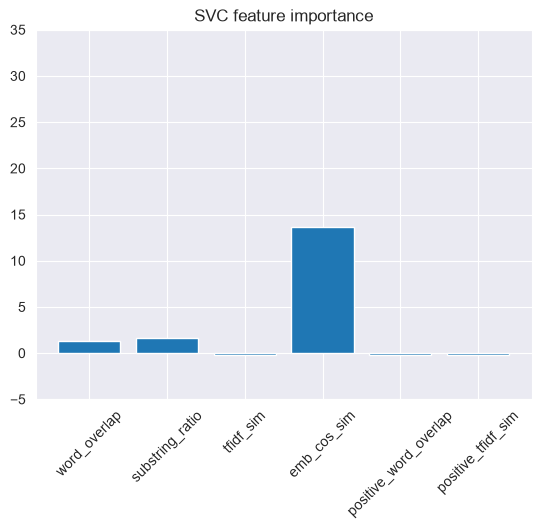

In [40]:
# plt.bar(num_cols, pipe_SVC['model'].coef_[0])
# plt.xticks(rotation=45)
# plt.ylim(-5, 35)
# plt.title('SVC feature importance')
# plt.show()

num_cols = ['word_overlap', 'substring_ratio', 'tfidf_sim', 'emb_cos_sim', 'positive_word_overlap', 'positive_tfidf_sim']

plt.bar(num_cols, pipe_SVC['model'].coef_[0])
plt.xticks(rotation=45)
plt.ylim(-5, 35)
plt.title('SVC feature importance')
plt.show()

In [41]:
y_proba_SVC = pipe_SVC.decision_function(x_val)

Embedding (passage:): 100%|██████████| 499/499 [00:58<00:00,  8.49it/s]


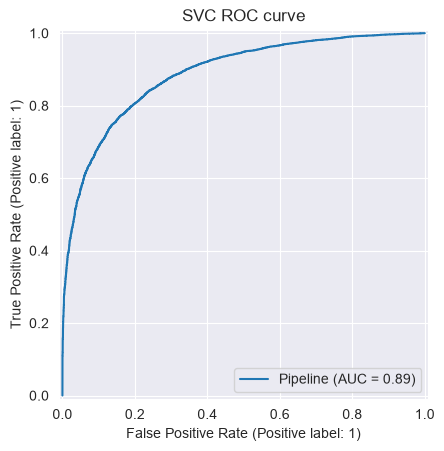

In [42]:
from sklearn.metrics import roc_auc_score, RocCurveDisplay

RocCurveDisplay.from_estimator(pipe_SVC, x_val, y_val)
plt.title('SVC ROC curve')
plt.show()

In [43]:
versus_model_dict = {'SVC' : (y_proba_SVC, roc_auc_score(y_val, y_proba_SVC), 112)} #112ms

### LogReg

In [44]:
pipe_logreg = Pipeline([
    ('preprocessor', preprocessor),
    ('binarizer', binarizer),
    ('model', LogisticRegression(C=1.0,                    # C = 1/lambda (C меньше = сильнее)
                        max_iter=10000,           # по умолчанию 1000
                        class_weight='balanced')  # 👇 если классы несбалансированы. None -- втупую без учета частоты класса
    )])

In [45]:
pipe_logreg.fit(x_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('binarizer', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
,"transformer_list transformer_list: list of (str, transformer) tuplesList of transformer objects to be applied to the data. The firsthalf of each tuple is the name of the transformer. The transformer canbe 'drop' for it to be ignored or can be 'passthrough' for features tobe passed unchanged... versionadded:: 1.1 Added the option `""passthrough""`... versionchanged:: 0.22 Deprecated `None` as a transformer in favor of 'drop'.","[('word_overlap', ...), ('substring_ratio', ...), ...]"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer.Keys are transformer names, values the weights.Raises ValueError if key not present in ``transformer_list``.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, default=TrueIf True, :meth:`get_feature_names_out` will prefix all feature nameswith the name of the transformer that generated that feature.If False, :meth:`get_feature_names_out` will not prefix any featurenames and will error if feature names are not unique... versionadded:: 1.5",True


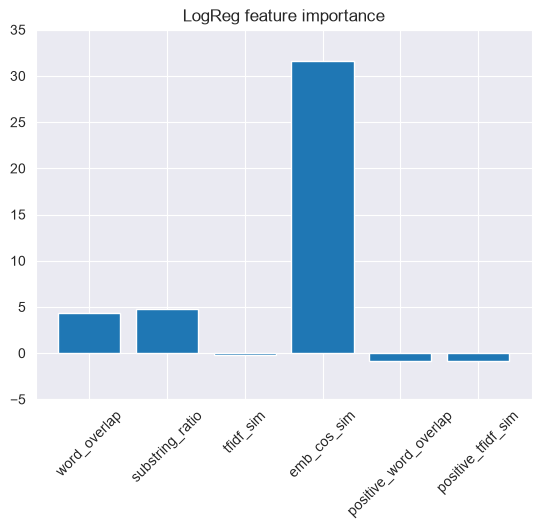

In [46]:
plt.bar(num_cols, pipe_logreg['model'].coef_[0])
plt.xticks(rotation=45)
plt.ylim(-5, 35)
plt.title('LogReg feature importance')
plt.show()

In [ ]:
y_proba_logreg = pipe_logreg.predict_proba(x_val)[:, 1]

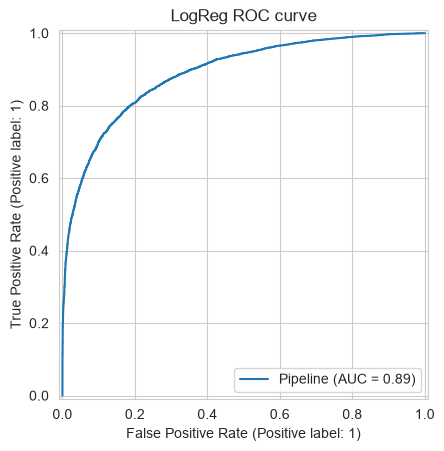

In [193]:
RocCurveDisplay.from_estimator(pipe_logreg, x_val, y_val)
plt.title('LogReg ROC curve')
plt.show()

In [132]:
versus_model_dict['LogReg'] = (y_proba_logreg, roc_auc_score(y_val, y_proba_logreg), 116)

### Random Forest

In [67]:
pipe_randfor = Pipeline([
    ('preprocessor', preprocessor),
    ('binarizer', binarizer),
    ('model', RandomForestClassifier(
        n_estimators=1000,   # количество деревьев (для небольших задач ML -- до 1000)
        max_depth=10,        
        min_samples_leaf=5,
        class_weight='balanced')
)])

In [109]:
pipe_randfor.fit(x_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](6,)","['word_overlap','substring_ratio','tfidf_sim','emb_cos_sim', 'positive_tfidf_sim','positive_word_overlap']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,6
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",1000
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",5


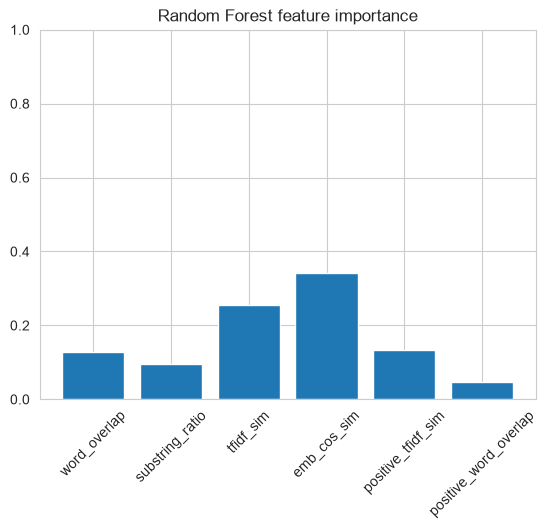

In [191]:
plt.bar(num_cols, pipe_randfor['model'].feature_importances_)
plt.xticks(rotation=45)
plt.ylim(0, 1)
plt.title('Random Forest feature importance')
plt.show()

In [116]:
y_proba_randfor = pipe_randfor.predict_proba(x_val)[:, 1]

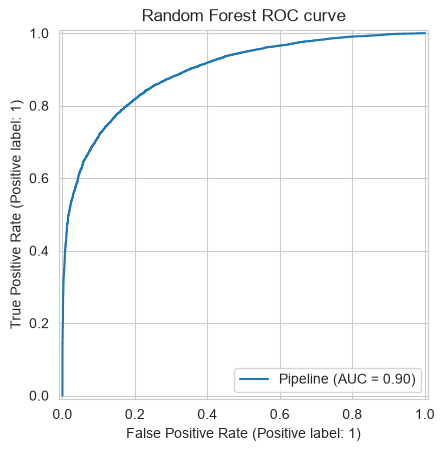

In [194]:
RocCurveDisplay.from_estimator(pipe_randfor, x_val, y_val)
plt.title('Random Forest ROC curve')
plt.show()

In [155]:
versus_model_dict['Random Forest'] = (y_proba_randfor, roc_auc_score(y_val, y_proba_randfor), 55647)

### GradBoost

In [48]:
pipe_gradboost_stage1 = Pipeline([
    ('preprocessor', preprocessor),
    ('binarizer', binarizer),
    ('model', GradientBoostingClassifier(
        n_estimators=100,   
        learning_rate=0.1,
        max_depth=3)
)])

In [49]:
pipe_gradboost_stage1.fit(x_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('binarizer', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
,"transformer_list transformer_list: list of (str, transformer) tuplesList of transformer objects to be applied to the data. The firsthalf of each tuple is the name of the transformer. The transformer canbe 'drop' for it to be ignored or can be 'passthrough' for features tobe passed unchanged... versionadded:: 1.1 Added the option `""passthrough""`... versionchanged:: 0.22 Deprecated `None` as a transformer in favor of 'drop'.","[('word_overlap', ...), ('substring_ratio', ...), ...]"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer.Keys are transformer names, values the weights.Raises ValueError if key not present in ``transformer_list``.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, default=TrueIf True, :meth:`get_feature_names_out` will prefix all feature nameswith the name of the transformer that generated that feature.If False, :meth:`get_feature_names_out` will not prefix any featurenames and will error if feature names are not unique... versionadded:: 1.5",True


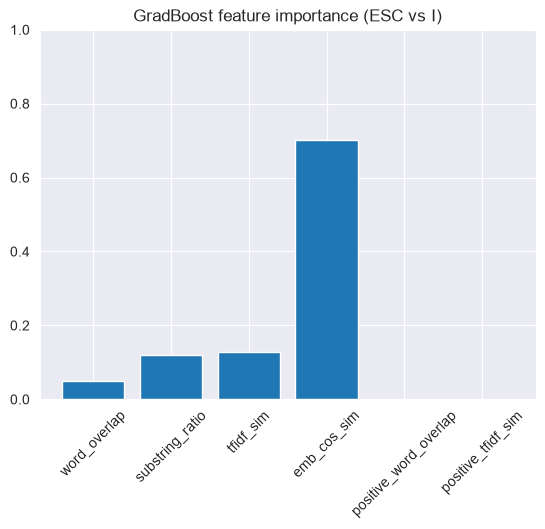

In [50]:
plt.bar(num_cols, pipe_gradboost_stage1['model'].feature_importances_)
plt.xticks(rotation=45)
plt.ylim(0, 1)
plt.title('GradBoost feature importance (ESC vs I)')
plt.show()

In [51]:
y_proba_gradboost = pipe_gradboost_stage1.predict_proba(x_val)[:, 1]

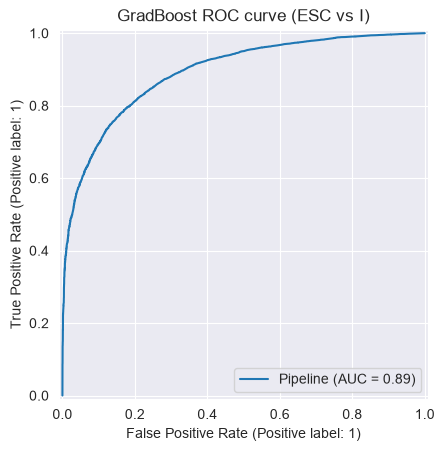

In [52]:
RocCurveDisplay.from_estimator(pipe_gradboost_stage1, x_val, y_val)
plt.title('GradBoost ROC curve (ESC vs I)')
plt.show()

In [53]:
versus_model_dict['GradBoost'] = (y_proba_gradboost, roc_auc_score(y_val, y_proba_gradboost), 4100)

### сравнение метрик и времени

In [157]:
model_names = ['SVC','LogReg','Random Forest','GradBoost']
model_metrics, model_times = [], []
for model_name in model_names:
    model_metrics.append(versus_model_dict[model_name][1])
    model_times.append(versus_model_dict[model_name][2])

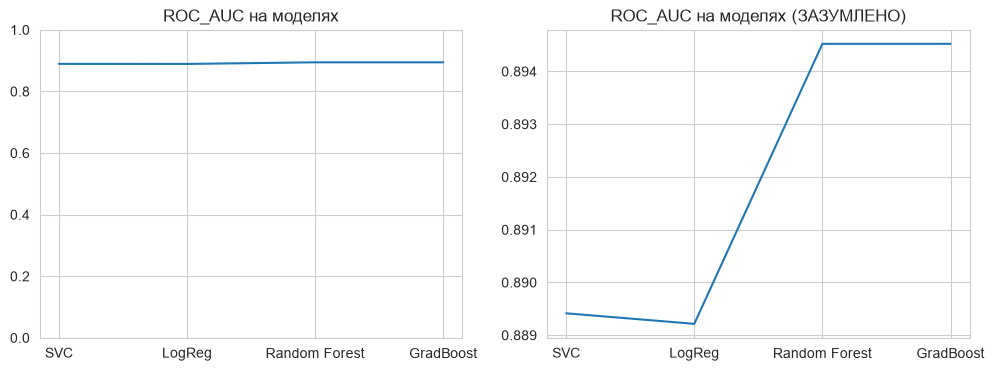

In [230]:
_, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(model_names, model_metrics)
ax1.set_ylim(0,1)
ax1.set_title('ROC_AUC на моделях (ESC vs I)')

ax2.plot(model_names, model_metrics)
ax2.set_title('ROC_AUC на моделях (ESC vs I) (ЗАЗУМЛЕНО)')

plt.show()

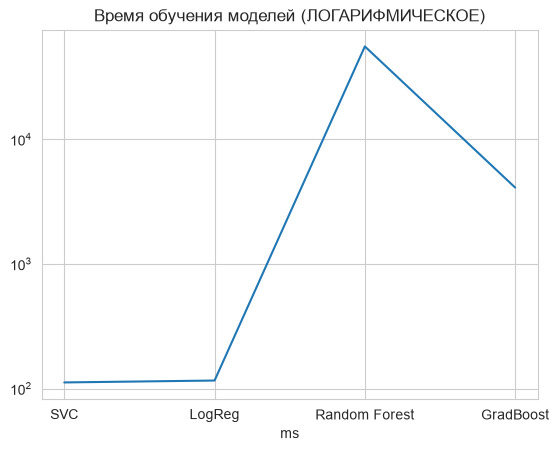

In [185]:
plt.plot(model_names, model_times)
plt.yscale('log')
plt.title('Время обучения моделей (ESC vs I) (ЛОГАРИФМИЧЕСКОЕ)')
plt.xlabel('ms')

plt.show()

## ML (E vs S vs C)

### GradBoost

#### обучение 

In [54]:
# stage 2: обучается только на строках, где I исключён (E/S/C)
x2 = df[df['target_ESC'] > 0][['query', 'item_name']]
y2 = df[df['target_ESC'] > 0]['target_ESC']   # 1=C, 2=S, 3=E

x2_train, x2_val, y2_train, y2_val = train_test_split(x2, y2, test_size=0.2)

In [55]:
from sklearn.base import clone

pipe_gradboost_stage2 = Pipeline([
    ('preprocessor', clone(preprocessor)),
    ('binarize', clone(binarizer)),
    ('model', GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3))
])

pipe_gradboost_stage2.fit(x2_train, y2_train)

Embedding (passage:): 100%|██████████| 1266/1266 [02:23<00:00,  8.80it/s]


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('binarize', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](3,)","[1,2,3]"
,"transformer_list transformer_list: list of (str, transformer) tuplesList of transformer objects to be applied to the data. The firsthalf of each tuple is the name of the transformer. The transformer canbe 'drop' for it to be ignored or can be 'passthrough' for features tobe passed unchanged... versionadded:: 1.1 Added the option `""passthrough""`... versionchanged:: 0.22 Deprecated `None` as a transformer in favor of 'drop'.","[('word_overlap', ...), ('substring_ratio', ...), ...]"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer.Keys are transformer names, values the weights.Raises ValueError if key not present in ``transformer_list``.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, default=TrueIf True, :meth:`get_feature_names_out` will prefix all feature nameswith the name of the transformer that generated that feature.If False, :meth:`get_feature_names_out` will not prefix any featurenames and will error if feature names are not unique... versionadded:: 1.5",True


In [56]:
def predict_two_stage(x):
    stage1_pred = pipe_gradboost_stage1.predict(x)          # 0 = I, 1 = не-I (уже обученный ранее)
    result = np.full(len(x), 1)                       # по умолчанию C=1 (для тех, кто I)

    mask_not_i = stage1_pred == 1
    if mask_not_i.sum() > 0:
        x_notI = x[mask_not_i]
        stage2_pred = pipe_gradboost_stage2.predict(x_notI)   # 1/2/3 = C/S/E
        result[mask_not_i] = stage2_pred
    return result

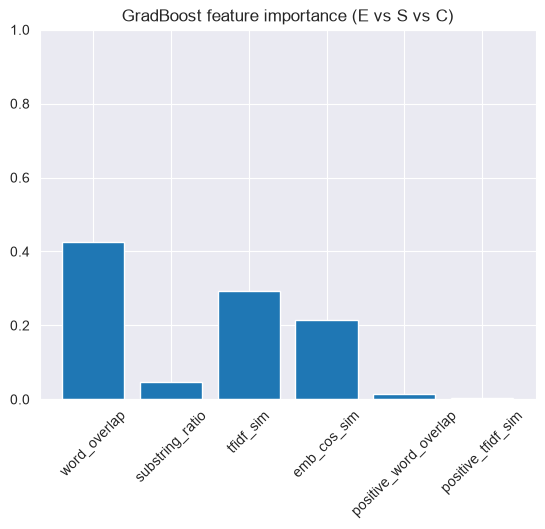

In [57]:
plt.bar(num_cols, pipe_gradboost_stage2['model'].feature_importances_)
plt.xticks(rotation=45)
plt.ylim(0, 1)
plt.title('GradBoost feature importance (E vs S vs C)')
plt.show()

#### инференс на 4 классах (E vs S vs C vs I)

In [64]:
def predict_full_4class(x):
    stage1_pred = pipe_gradboost_stage1.predict(x)   # 0 = I, 1 = не-I
    result = np.zeros(len(x), dtype=int)              # по умолчанию I = 0

    mask_not_i = stage1_pred == 1
    if mask_not_i.sum() > 0:
        x_notI = x[mask_not_i]
        stage2_pred = pipe_gradboost_stage2.predict(x_notI)   # 1/2/3 = C/S/E
        result[mask_not_i] = stage2_pred
    return result

In [65]:
final_preds = predict_full_4class(x_val)
y_true = df.loc[x_val.index, 'target_ESC']

Embedding (passage:): 100%|██████████| 323/323 [00:39<00:00,  8.27it/s]


In [ ]:
# RocCurveDisplay.from_estimator(pipe_gradboost_stage2, x2_val, y2_val)
# plt.title('GradBoost ROC curve (E vs S vs C)')
# plt.show()

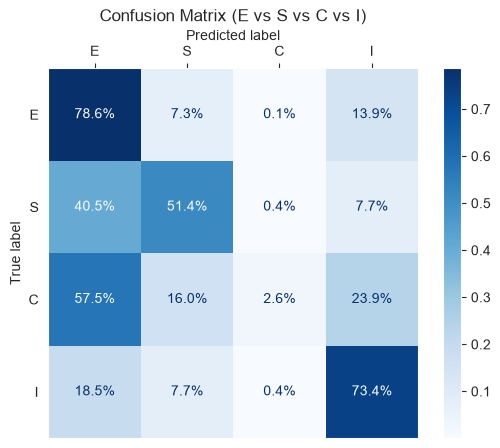

In [91]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# cm = confusion_matrix(y_true, final_preds, labels=[3, 2, 1, 0])  # E, S, C, I
# disp = ConfusionMatrixDisplay(cm, display_labels=['E', 'S', 'C', 'I'])
# disp.plot(cmap='Blues')
cm_norm = confusion_matrix(y_true, final_preds, labels=[3,2,1,0], normalize='true')
disp = ConfusionMatrixDisplay(cm_norm, display_labels=['E','S','C','I'])
disp.plot(cmap='Blues', values_format='.1%')
disp.ax_.xaxis.set_label_position('top')
disp.ax_.xaxis.tick_top()
disp.ax_.grid(False)
plt.title('Confusion Matrix (E vs S vs C vs I)')
plt.show()

F1 macro (весь pipeline, 4 класса): 0.505

              precision    recall  f1-score   support

           I       0.75      0.73      0.74      5774
           C       0.43      0.03      0.05      1011
           S       0.46      0.51      0.49      1895
           E       0.70      0.79      0.74      7275

    accuracy                           0.69     15955
   macro avg       0.59      0.51      0.50     15955
weighted avg       0.67      0.69      0.67     15955



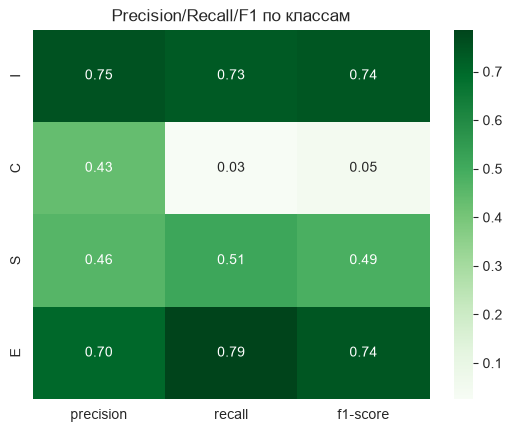

In [74]:
from sklearn.metrics import f1_score, classification_report

f1_full = f1_score(y_true, final_preds, average='macro')

print(f'F1 macro (весь pipeline, 4 класса): {f1_full:.3f}')
print()
print(classification_report(y_true, final_preds, target_names=['I', 'C', 'S', 'E'], labels=[0, 1, 2, 3]))



import seaborn as sns
from sklearn.metrics import classification_report

report = classification_report(y_true, final_preds, target_names=['I','C','S','E'], labels=[0,1,2,3], output_dict=True)
report_df = pd.DataFrame(report).iloc[:-1, :4].T  # без строк accuracy/macro avg/weighted avg, только по классам

sns.heatmap(report_df, annot=True, cmap='Greens', fmt='.2f')
plt.title('Precision/Recall/F1 по классам')
plt.show()